# Study 2: Prompt Reliability

**Research framework:** Törnberg (2024) and Barrie et al. (2025) identify prompt sensitivity as a key validity threat for LLM annotation. This study tests whether minor prompt rewording (Phase 1) or deliberate ideological framing of the system prompt (Phase 2) shifts AAPA annotations meaningfully, threatening the reliability established in Study 1.

| Phase | Focus | Design |
|---|---|---|
| 1 | Prompt stability | Canonical codebook (Prompt A) vs rephrased codebook (Prompt B)  (2,000 tweets x 2 codebooks) |
| 2 | Ideological skew | Neutral vs 4 ideologically framed system prompts (2,000 tweets × 5 conditions) |

**Primary model:** GPT-4o (`gpt-4o-2024-08-06`)  
**Dataset:** `sampled_tweets_2000.csv` 

GPT-4o selected as primary model based on Study 1 findings:
   - Highest and most consistent human alignment across interpretable variables
   - Strongest inter-LLM pairwise agreement (α = .752 with Claude Sonnet on V1)
   - Methodological standard in Jia et al. (2024) and Törnberg (2024)
   - Cost constraints precluded running all three Study 1 models at 2,000-tweet scale

## 0. Configuration

In [1]:
import os
import sys
import time
import json
import re
from datetime import datetime

import pandas as pd
import numpy as np
from tqdm import tqdm
from dotenv import load_dotenv
from openai import OpenAI
from scipy.stats import spearmanr
import krippendorff
import warnings
warnings.filterwarnings("ignore")

load_dotenv()

OPENAI_API_KEY = os.getenv("OPENAI_API_KEY")
openai_client  = OpenAI(api_key=OPENAI_API_KEY)

PRIMARY_MODEL   = "gpt-4o-2024-08-06"
PRIMARY_DISPLAY = "GPT-4o"

INPUT_FILE  = "datasets/sampled_tweets_2000.csv"
OUTPUT_DIR  = "study2"
SCORE_COLS  = [f"V{i}" for i in range(1, 9)]

TEMPERATURE   = 0
MAX_RETRIES   = 10
RETRY_WAIT    = 15
REQUEST_DELAY = 1.5

os.makedirs(OUTPUT_DIR, exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "stability"), exist_ok=True)
os.makedirs(os.path.join(OUTPUT_DIR, "framing"),   exist_ok=True)

print("Configuration loaded.")
print(f"  Primary model : {PRIMARY_MODEL}")
print(f"  Input file    : {INPUT_FILE}")
print(f"  Output dir    : {OUTPUT_DIR}")

Configuration loaded.
  Primary model : gpt-4o-2024-08-06
  Input file    : datasets/sampled_tweets_2000.csv
  Output dir    : study2


## 1. Load Dataset

In [2]:
df = pd.read_csv(INPUT_FILE)
required_cols = ["tweet_id", "post_type", "text"]
missing = [c for c in required_cols if c not in df.columns]
if missing:
    raise ValueError(f"Missing required columns: {missing}")

df["tweet_id"]    = df["tweet_id"].astype(str)
df["text_length"] = df["text"].str.len()

print(f"Loaded {len(df)} tweets")
print(f"\nPost-type distribution (1=original, 2=reply, 3=retweet):")
print(df["post_type"].value_counts().to_string())
print(f"\nText length statistics:")
print(df["text_length"].describe().round(1).to_string())

Loaded 2000 tweets

Post-type distribution (1=original, 2=reply, 3=retweet):
post_type
reply    1027
tweet     702
quote     271

Text length statistics:
count    2000.0
mean      168.4
std        91.8
min         4.0
25%        91.0
50%       157.5
75%       253.0
max       898.0


## 2. Codebooks and Prompt Construction

**Prompt A:** Canonical codebook reproduced verbatim from Jia et al. (2024). Same prompt used in Study 1.

**Prompt B:** Surface-level rewording of Prompt A. Construct labels renamed and definitions paraphrased, but factor structures and rating scales are identical. Tests whether GPT-4o responds to semantic content or surface form.

In [3]:
OUTPUT_FORMAT = """
Respond ONLY with a JSON object in exactly this format (no extra fields, no markdown):
{
  "V1": {"score": <1|2|3>, "V1_reason": "<brief reason citing tweet language>"},
  "V2": {"score": <1|2|3>, "V2_reason": "<brief reason citing tweet language>"},
  "V3": {"score": <1|2|3>, "V3_reason": "<brief reason citing tweet language>"},
  "V4": {"score": <1|2|3>, "V4_reason": "<brief reason citing tweet language>"},
  "V5": {"score": <1|2|3>, "V5_reason": "<brief reason citing tweet language>"},
  "V6": {"score": <1|2|3>, "V6_reason": "<brief reason citing tweet language>"},
  "V7": {"score": <1|2|3>, "V7_reason": "<brief reason citing tweet language>"},
  "V8": {"score": <1|2|3>, "V8_reason": "<brief reason citing tweet language>"}
}
"""

SYSTEM_PROMPT_NEUTRAL = """You are an expert political content annotator trained in political science. 
Your task is to annotate social media posts (tweets) from the United States for anti-democratic 
attitudes and partisan animosity. You will apply a structured codebook derived from the 
Anti-democratic Attitudes and Partisan Animosity (AAPA) scale used in academic research.

You must rate each tweet on EIGHT variables (V1-V8), each on a scale of 1 to 3.
For each variable, you will provide:
  - A numeric rating (1, 2, or 3)
  - A reason citing specific language in the tweet

You MUST respond ONLY with a valid JSON object. Do not include any text before or after the JSON.
Do not include markdown code fences. Return only the raw JSON."""

# Prompt A: Canonical codebook (Jia et al., 2024) 
CODEBOOK_A = """
CODEBOOK: Anti-Democratic Attitudes and Partisan Animosity Scale

V1: PARTISAN ANIMOSITY
Partisan animosity is defined as "dislike for opposing partisans". 
Factors:
  A: Partisan name-calling
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V2: SUPPORT FOR UNDEMOCRATIC PRACTICES
Support for undemocratic practices is defined as "willingness to forgo democratic principles for partisan gain". 
Undemocratic practices are undemocratic tendencies or actions such as reducing polling stations in areas that 
support their opponents, attacking the independence of the judiciary, undermining the free press, and challenging 
the legitimacy of election results, and encouraging political violence. 
Factors:
  A: Shows support for undemocratic practices
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Does not satisfy A, but satisfies B1 or B2
  3 = Satisfies A, B1, and B2

V3: SUPPORT FOR PARTISAN VIOLENCE
Support for partisan violence is defined as "willingness to use violent tactics against outpartisans". 
Examples of partisan violence include sending threatening and intimidating messages to the opponent party, 
harassing the opponent party on the Internet, using violence in advancing their political goals or winning 
more races in the next election.
Factors:
  A: Shows support for partisan violence
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Does not satisfy A, but satisfies B1 or B2
  3 = Satisfies A, B1, and B2

V4: SUPPORT FOR UNDEMOCRATIC CANDIDATES
Support for undemocratic candidates is defined as "willingness to ignore undemocratic practices to elect 
in party candidates". 
Factors:
  A: Shows support for undemocratic candidates
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Satisfies A, but not B1 or B2
  3 = Satisfies A, B1, and B2

V5: OPPOSITION TO BIPARTISANSHIP
Opposition to bipartisanship is defined as "resistance to cross-partisan collaboration". 
Factors:
  A: Any name-calling or terms that reduce trust
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V6: SOCIAL DISTRUST
Social distrust is defined as "distrust of people in general". 
Factors:
  A: Any name-calling or terms that reduce trust
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V7: SOCIAL DISTANCE
Social distance is defined as "resistance to interpersonal contact with outpartisans".
Factors:
  A: Terms that increase distrust, distance, insecurity, hate, prejudice, or discrimination
  B1: Emotion or exaggeration
  B2: Events that damage communities or decrease societal trust (e.g. mass shooting)
Ratings:
  1 = Does not satisfy any factor
  2 = Satisfies A, but not B1 or B2
  3 = Satisfies A, and B1 or B2

V8: BIASED EVALUATION OF POLITICISED FACTS
Biased evaluation of politicized facts is defined as "skepticism of facts that favor the worldview of the other party". 
Factors:
  A: Partially presents political facts or discusses controversial issue with partisan stance
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist
"""

# Prompt B: Paraphrased codebook (rewording, identical factor structure)
CODEBOOK_B = """
CODEBOOK: Anti-Democratic Attitudes and Partisan Animosity Scale

V1: INTERPARTY HOSTILITY
Interparty hostility is defined as "negative affect directed toward members of the opposing political party".
Factors:
  A: Partisan name-calling
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V2: ENDORSEMENT OF NORM-VIOLATING CONDUCT
Endorsement of norm-violating conduct is defined as "readiness to sacrifice democratic norms in pursuit of partisan advantage".
Norm-violating conduct encompasses anti-democratic behaviors such as limiting ballot access in opposition strongholds, 
undermining judicial autonomy, suppressing independent media, contesting the validity of electoral outcomes, 
and inciting politically motivated violence.
Factors:
  A: Shows support for undemocratic practices
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Does not satisfy A, but satisfies B1 or B2
  3 = Satisfies A, B1, and B2

V3: ACCEPTANCE OF POLITICAL AGGRESSION
Acceptance of political aggression is defined as "approval of forceful or threatening tactics directed at members of the opposing party".
Examples include delivering threatening communications to rival partisans, coordinating online harassment campaigns, 
and endorsing the use of coercive force to achieve electoral or political objectives.
Factors:
  A: Shows support for partisan violence
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Does not satisfy A, but satisfies B1 or B2
  3 = Satisfies A, B1, and B2

V4: TOLERANCE OF AUTHORITARIAN CANDIDATES
Tolerance of authoritarian candidates is defined as "willingness to overlook anti-democratic behavior in order to support co-partisan electoral prospects".
Factors:
  A: Shows support for undemocratic candidates
  B1: Partisan name-calling
  B2: Emotion or exaggeration
Ratings:
  1 = Does not satisfy any factor
  2 = Satisfies A, but not B1 or B2
  3 = Satisfies A, B1, and B2

V5: REJECTION OF CROSS-PARTY COOPERATION
Rejection of cross-party cooperation is defined as "unwillingness to engage in or accept collaborative efforts that span partisan lines".
Factors:
  A: Any name-calling or terms that reduce trust
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V6: GENERALIZED INTERPERSONAL SUSPICION
Generalized interpersonal suspicion is defined as "a broad tendency to doubt the intentions or reliability of others in society".
Factors:
  A: Any name-calling or terms that reduce trust
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist

V7: OUTPARTY AVOIDANCE
Outparty avoidance is defined as "preference for limiting personal or social contact with those affiliated with the opposing party".
Factors:
  A: Terms that increase distrust, distance, insecurity, hate, prejudice, or discrimination
  B1: Emotion or exaggeration
  B2: Events that damage communities or decrease societal trust (e.g. public health crisis)
Ratings:
  1 = Does not satisfy any factor
  2 = Satisfies A, but not B1 or B2
  3 = Satisfies A, and B1 or B2

V8: PARTISAN DISTORTION OF FACTUAL CLAIMS
Partisan distortion of factual claims is defined as "tendency to dismiss or contest information that appears to support the opposing party's narrative".
Factors:
  A: Partially presents political facts or discusses controversial issue with partisan stance
  B: Emotion or exaggeration
Ratings:
  1 = Neither A nor B exists
  2 = One of A or B exists
  3 = Both A and B exist
"""


def build_prompt_a(tweet_text: str, post_type: str) -> str:
    return f"""{CODEBOOK_A}
{OUTPUT_FORMAT}
Now annotate the following {post_type}:
\"{tweet_text}\""""

def build_prompt_b(tweet_text: str, post_type: str) -> str:
    return f"""{CODEBOOK_B}
{OUTPUT_FORMAT}
Annotate this {post_type}:
\"{tweet_text}\""""

print("Codebooks and prompt builders defined")
print(f"Prompt A length: {len(build_prompt_a('test', 'tweet'))} chars")
print(f"Prompt B length: {len(build_prompt_b('test', 'tweet'))} chars")

Codebooks and prompt builders defined
Prompt A length: 4178 chars
Prompt B length: 4454 chars


## 3. Ideological System Prompts

Five system prompt conditions for Phase 2. The codebook (Prompt A) and rating scale are identical across all conditions. Only the system prompt framing changes.

| Condition | Type | Design intent |
|---|---|---|
| Neutral | Baseline | Identical to Study 1 |
| Subtle liberal | Subtle | Inclusive democracy, regulatory, environmental framing |
| Subtle conservative | Subtle | Constitutional order, limited government, institutional stability framing |
| Extreme Democrat | Explicit | Right-wing threat salience |
| Extreme Republican | Explicit | Left-wing threat salience |

In [4]:
SYSTEM_PROMPTS = {
    "neutral": SYSTEM_PROMPT_NEUTRAL,

    "subtle_liberal":
    """You are an expert political content annotator trained in political science. 
Your academic background has oriented you toward questions of inclusive, multiracial 
democracy, the regulation of markets in the public interest, environmental protection, 
immigrant inclusion, and gun safety. Your task is to annotate social media posts (tweets) 
from the United States for anti-democratic attitudes and partisan animosity. You will apply 
a structured codebook derived from the Anti-democratic Attitudes and Partisan Animosity 
(AAPA) scale used in academic research. You are attentive to threats to democratic norms
that can arise from any political side.

You must rate each tweet on EIGHT variables (V1-V8), each on a scale of 1 to 3.
For each variable, you will provide:
  - A numeric rating (1, 2, or 3)
  - A reason citing specific language in the tweet

You MUST respond ONLY with a valid JSON object. Do not include any text before or after the JSON.
Do not include markdown code fences. Return only the raw JSON.""",

    "subtle_conserv":
    """You are an expert political content annotator trained in political science. 
Your academic background has oriented you toward questions of limited government, 
constitutional order, election integrity, respect for traditional American institutions, 
strong gun rights, and scepticism of expansive regulatory overreach. Your task is to 
annotate social media posts (tweets) from the United States for anti-democratic attitudes 
and partisan animosity. You will apply a structured codebook derived from the 
Anti-democratic Attitudes and Partisan Animosity (AAPA) scale used in academic research. 
You are attentive to threats to democratic norms that can arise from any political side.

You must rate each tweet on EIGHT variables (V1-V8), each on a scale of 1 to 3.
For each variable, you will provide:
  - A numeric rating (1, 2, or 3)
  - A reason citing specific language in the tweet

You MUST respond ONLY with a valid JSON object. Do not include any text before or after the JSON.
Do not include markdown code fences. Return only the raw JSON.""",

    "extreme_dem":
    """You are an expert political content annotator trained in political science. 
You are focused on upholding democratic norms against the threats posed by Republican 
elites, MAGA Republicans, and far-right activists, who represent the primary contemporary 
source of democratic backsliding through efforts to undermine free and fair elections, 
the peaceful transfer of power, and the rule of law. Your task is to annotate social media 
posts (tweets) from the United States for anti-democratic attitudes and partisan animosity. 
You will apply a structured codebook derived from the Anti-democratic Attitudes and 
Partisan Animosity (AAPA) scale used in academic research.

You must rate each tweet on EIGHT variables (V1-V8), each on a scale of 1 to 3.
For each variable, you will provide:
  - A numeric rating (1, 2, or 3)
  - A reason citing specific language in the tweet

You MUST respond ONLY with a valid JSON object. Do not include any text before or after the JSON.
Do not include markdown code fences. Return only the raw JSON.""",

    "extreme_rep":
    """You are an expert political content annotator trained in political science. 
You are focused on upholding democratic norms against the threats posed by Democratic 
elites, radical Democrats, and far-left activists, who represent the primary contemporary 
source of democratic backsliding through efforts to suppress free speech, weaponise 
federal institutions against political opponents, and erode constitutional freedoms. 
Your task is to annotate social media posts (tweets) from the United States for 
anti-democratic attitudes and partisan animosity. You will apply a structured codebook 
derived from the Anti-democratic Attitudes and Partisan Animosity (AAPA) scale used 
in academic research.

You must rate each tweet on EIGHT variables (V1-V8), each on a scale of 1 to 3.
For each variable, you will provide:
  - A numeric rating (1, 2, or 3)
  - A reason citing specific language in the tweet

You MUST respond ONLY with a valid JSON object. Do not include any text before or after the JSON.
Do not include markdown code fences. Return only the raw JSON.""",
}

FRAMING_LABELS = ["subtle_liberal", "subtle_conserv", "extreme_dem", "extreme_rep"]
print(f"System prompts defined: {list(SYSTEM_PROMPTS.keys())}")

System prompts defined: ['neutral', 'subtle_liberal', 'subtle_conserv', 'extreme_dem', 'extreme_rep']


## 4. API Helpers

In [5]:
def parse_json_response(raw_text: str) -> dict:
    cleaned = re.sub(r"```(?:json)?\s*", "", raw_text).strip().rstrip("`").strip()
    try:
        return json.loads(cleaned)
    except json.JSONDecodeError as e:
        raise ValueError(f"Failed to parse JSON.\nRaw: {raw_text[:200]}\nError: {e}")


def validate_annotation(annotation: dict) -> dict:
    for v in SCORE_COLS:
        if v not in annotation:
            raise ValueError(f"Missing variable {v}")
        score = annotation[v].get("score")
        if score not in [1, 2, 3]:
            raise ValueError(f"Invalid score for {v}: {score}")
    return annotation


def annotate_openai(tweet_text: str, post_type: str,
                    model: str = PRIMARY_MODEL,
                    prompt_fn=build_prompt_a,
                    system_prompt: str = SYSTEM_PROMPT_NEUTRAL) -> dict:
    for attempt in range(MAX_RETRIES):
        try:
            response = openai_client.chat.completions.create(
                model=model,
                temperature=TEMPERATURE,
                response_format={"type": "json_object"},
                messages=[
                    {"role": "system", "content": system_prompt},
                    {"role": "user",   "content": prompt_fn(tweet_text, post_type)},
                ]
            )
            raw = response.choices[0].message.content
            return validate_annotation(parse_json_response(raw))
        except Exception as e:
            print(f"  [OpenAI] Attempt {attempt+1}/{MAX_RETRIES} failed: {e}")
            if attempt < MAX_RETRIES - 1:
                time.sleep(RETRY_WAIT * (attempt + 1))
            else:
                raise RuntimeError(f"OpenAI failed after {MAX_RETRIES} attempts: {e}")


def load_checkpoint(path: str) -> set:
    if os.path.exists(path):
        with open(path) as f:
            data = json.load(f)
        completed = set(tuple(x) for x in data.get("completed", []))
        print(f"  Checkpoint loaded: {len(completed)} items done")
        return completed
    return set()


def save_checkpoint(completed: set, path: str):
    with open(path, "w") as f:
        json.dump({"completed": [list(x) for x in completed]}, f)


def annotation_to_row(tweet_row, annotation, annotation_id, session, extra_cols=None):
    scores  = {v: annotation[v]["score"]       for v in SCORE_COLS}
    reasons = {v: annotation[v][f"{v}_reason"] for v in SCORE_COLS}
    row = {
        "annotation_id":      annotation_id,
        "tweet_id":           tweet_row["tweet_id"],
        "llm_name_version":   PRIMARY_MODEL,
        "post_type":          tweet_row["post_type"],
        "text":               tweet_row["text"],
        "total_score":        sum(scores.values()),
        "date":               datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "annotation_session": session,
    }
    for v in SCORE_COLS:
        row[v]             = scores[v]
        row[f"{v}_reason"] = reasons[v]
    if extra_cols:
        row.update(extra_cols)
    return row


print("API helpers defined.")

API helpers defined.


---
## Phase 1: Prompt Stability

Tests whether surface-level rewording of the canonical codebook shifts GPT-4o's annotations. 
High Spearman ρ (> 0.80) and Krippendorff's α (> 0.67) across variables indicates the model responds to construct meaning rather than surface keywords.

**Design:** 2,000 tweets × 2 codebook variants = 4,000 API calls  
**Output:** `study2/stability/prompt_stability_results.csv`

In [6]:
STABILITY_CHECKPOINT = os.path.join(OUTPUT_DIR, "stability", "checkpoint_phase1.json")
STABILITY_OUTPUT     = os.path.join(OUTPUT_DIR, "stability", "prompt_stability_results.csv")

stability_completed = load_checkpoint(STABILITY_CHECKPOINT)
stability_results   = []
annotation_id       = 1

if os.path.exists(STABILITY_OUTPUT):
    existing_stab     = pd.read_csv(STABILITY_OUTPUT)
    stability_results = existing_stab.to_dict("records")
    annotation_id     = len(stability_results) + 1
    print(f"  Resuming: {len(stability_results)} rows already saved")

total_stab = len(df) * 2
done_stab  = len(stability_completed)
print(f"\nPhase 1: Prompt stability")
print(f"  Total API calls : {total_stab}")
print(f"  Done            : {done_stab}")
print(f"  Remaining       : {total_stab - done_stab}")

  Checkpoint loaded: 4000 items done
  Resuming: 4000 rows already saved

Phase 1: Prompt stability
  Total API calls : 4000
  Done            : 4000
  Remaining       : 0


In [7]:
session = datetime.now().strftime("%Y%m%d_%H%M")

with tqdm(total=total_stab - done_stab, desc="Phase 1: Prompt stability") as pbar:
    for _, tweet_row in df.iterrows():
        tid = tweet_row["tweet_id"]
        for prompt_label, prompt_fn in [("A", build_prompt_a), ("B", build_prompt_b)]:
            key = (tid, prompt_label)
            if key in stability_completed:
                continue
            try:
                annotation = annotate_openai(
                    tweet_row["text"], tweet_row["post_type"],
                    prompt_fn=prompt_fn,
                    system_prompt=SYSTEM_PROMPT_NEUTRAL
                )
                row = annotation_to_row(
                    tweet_row, annotation, annotation_id, session,
                    extra_cols={"prompt_variant": prompt_label}
                )
                stability_results.append(row)
                annotation_id += 1
                stability_completed.add(key)
                save_checkpoint(stability_completed, STABILITY_CHECKPOINT)
                if len(stability_results) % 20 == 0:
                    pd.DataFrame(stability_results).to_csv(STABILITY_OUTPUT, index=False)
                time.sleep(REQUEST_DELAY)
                pbar.update(1)
            except Exception as e:
                print(f"Failed: tweet {tid}, prompt {prompt_label}: {e}")
                continue

pd.DataFrame(stability_results).to_csv(STABILITY_OUTPUT, index=False)
print(f"\nPhase 1 complete. {len(stability_results)} rows saved.")

Phase 1: Prompt stability: 0it [00:00, ?it/s]


Phase 1 complete. 4000 rows saved.


### Phase 1: Analysis

Spearman ρ and Krippendorff's α (ordinal) are computed pairwise between Prompt A and Prompt B for each variable. 

MAD provides the interpretable score-level shift.

In [8]:
def krippendorff_alpha(matrices, variable):
    try:
        data = np.array([m[variable].values for m in matrices], dtype=float)
        return krippendorff.alpha(reliability_data=data, level_of_measurement="ordinal")
    except Exception:
        return np.nan


stab_df  = pd.read_csv(STABILITY_OUTPUT)
prompt_a = stab_df[stab_df["prompt_variant"] == "A"].set_index("tweet_id")[SCORE_COLS]
prompt_b = stab_df[stab_df["prompt_variant"] == "B"].set_index("tweet_id")[SCORE_COLS]
common   = sorted(set(prompt_a.index) & set(prompt_b.index))
prompt_a = prompt_a.loc[common]
prompt_b = prompt_b.loc[common]

print(f"Comparing {len(common)} tweets × 2 prompts\n")
print(f"{'Variable':<8} {'Spearman ρ':>12} {'p-value':>10} {'α (ord)':>10} {'MAD':>8} {'% exact':>10} {'Verdict'}")
print("-" * 70)

stability_records = []
for v in SCORE_COLS:
    a = prompt_a[v].values
    b = prompt_b[v].values
    rho, pval = spearmanr(a, b)
    mad       = float(np.mean(np.abs(a - b)))
    pct_exact = float(np.mean(a == b))
    alpha     = krippendorff_alpha([prompt_a[[v]], prompt_b[[v]]], v)
    stability_records.append({
        "variable":           v,
        "spearman_rho":       round(rho, 3),
        "p_value":            round(pval, 4),
        "krippendorff_alpha": round(alpha, 3) if not np.isnan(alpha) else np.nan,
        "MAD":                round(mad, 3),
        "pct_exact_agree":    round(pct_exact, 3),
    })
    verdict   = "Stable" if rho > 0.80 else "Acceptable" if rho > 0.60 else "Unstable"
    alpha_str = f"{alpha:.3f}" if not np.isnan(alpha) else "n/a"
    print(f"{v:<8} {rho:>12.3f} {pval:>10.4f} {alpha_str:>10} {mad:>8.3f} {pct_exact:>9.1%}  {verdict}")

stability_summary = pd.DataFrame(stability_records).set_index("variable")
stability_summary.to_csv(os.path.join(OUTPUT_DIR, "stability", "stability_summary.csv"))
print(f"\nSaved: stability_summary.csv")

Comparing 2000 tweets × 2 prompts

Variable   Spearman ρ    p-value    α (ord)      MAD    % exact Verdict
----------------------------------------------------------------------
V1              0.916     0.0000      0.914    0.081     92.0%  Stable
V2              0.724     0.0000      0.700    0.145     85.5%  Acceptable
V3              0.469     0.0000      0.374    0.111     88.9%  Unstable
V4              0.472     0.0000      0.389    0.042     95.8%  Unstable
V5              0.817     0.0000      0.817    0.127     87.3%  Stable
V6              0.775     0.0000      0.749    0.179     82.0%  Acceptable
V7              0.723     0.0000      0.694    0.134     86.6%  Acceptable
V8              0.785     0.0000      0.785    0.164     83.6%  Acceptable

Saved: stability_summary.csv


### Table P1: Prompt Stability Summary

In [9]:
display(stability_summary.round(3))

,spearman_rho,p_value,krippendorff_alpha,MAD,pct_exact_agree
variable,,,,,
V1,0.916,0.0,0.914,0.081,0.919
V2,0.724,0.0,0.700,0.145,0.855
V3,0.469,0.0,0.374,0.111,0.889
V4,0.472,0.0,0.389,0.042,0.958
V5,0.817,0.0,0.817,0.127,0.873
V6,0.775,0.0,0.749,0.179,0.821
V7,0.723,0.0,0.694,0.134,0.866
V8,0.785,0.0,0.785,0.164,0.836


### Shared Plot Configuration (Phase 1)

In [10]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker

STAB_FIGURE_DIR = os.path.join(OUTPUT_DIR, "stability", "figures")
os.makedirs(STAB_FIGURE_DIR, exist_ok=True)

VARIABLE_LABELS = {
    "V1": "V1\nPartisan\nAnimosity",
    "V2": "V2\nUndemocratic\nPractices",
    "V3": "V3\nPartisan\nViolence",
    "V4": "V4\nUndemocratic\nCandidates",
    "V5": "V5\nOpp. to\nBipartisanship",
    "V6": "V6\nSocial\nDistrust",
    "V7": "V7\nSocial\nDistance",
    "V8": "V8\nBiased Fact\nEvaluation",
}

THRESHOLD_STABLE     = 0.80
THRESHOLD_ACCEPTABLE = 0.67

COLOUR_STABLE     = "#148021"
COLOUR_ACCEPTABLE = "#F59E0B"
COLOUR_UNSTABLE   = "#EF4444"

LOW_VARIANCE = {"V3", "V4"}

plt.rcParams.update({
    "font.family":     "sans-serif",
    "font.sans-serif": ["Calibri", "Arial", "Helvetica"],
    "font.size":       8,
    "axes.titlesize":  9.5,
    "axes.labelsize":  8.5,
    "xtick.labelsize": 7.5,
    "ytick.labelsize": 7.5,
    "legend.fontsize": 7.5,
})


def get_var_colour(v, val, threshold_high=0.80, threshold_low=0.60):
    """Colour by reliability zone."""
    if val > threshold_high:
        return COLOUR_STABLE
    if val > threshold_low:
        return COLOUR_ACCEPTABLE
    return COLOUR_UNSTABLE


def style_axes(ax):
    ax.spines[["top", "right", "bottom"]].set_visible(False)
    ax.spines["left"].set_color("#CBD5E1")
    ax.tick_params(axis="both", labelsize=7.5)


def save_fig(fig, stem, figure_dir=STAB_FIGURE_DIR):
    path = os.path.join(figure_dir, stem + ".png")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {path}")


variables  = stability_summary.index.tolist()
rho_vals   = stability_summary["spearman_rho"].values
alpha_vals = stability_summary["krippendorff_alpha"].values
mad_vals   = stability_summary["MAD"].values
exact_vals = stability_summary["pct_exact_agree"].values
xi         = np.arange(len(variables))

print("Plot configuration loaded.")

Plot configuration loaded.


### Figure P1: Prompt Stability; Spearman ρ and Krippendorff's α Side-by-Side

Primary stability overview. Two panels show ρ and α together.

MAD encoded as dot size gives a third dimension. 

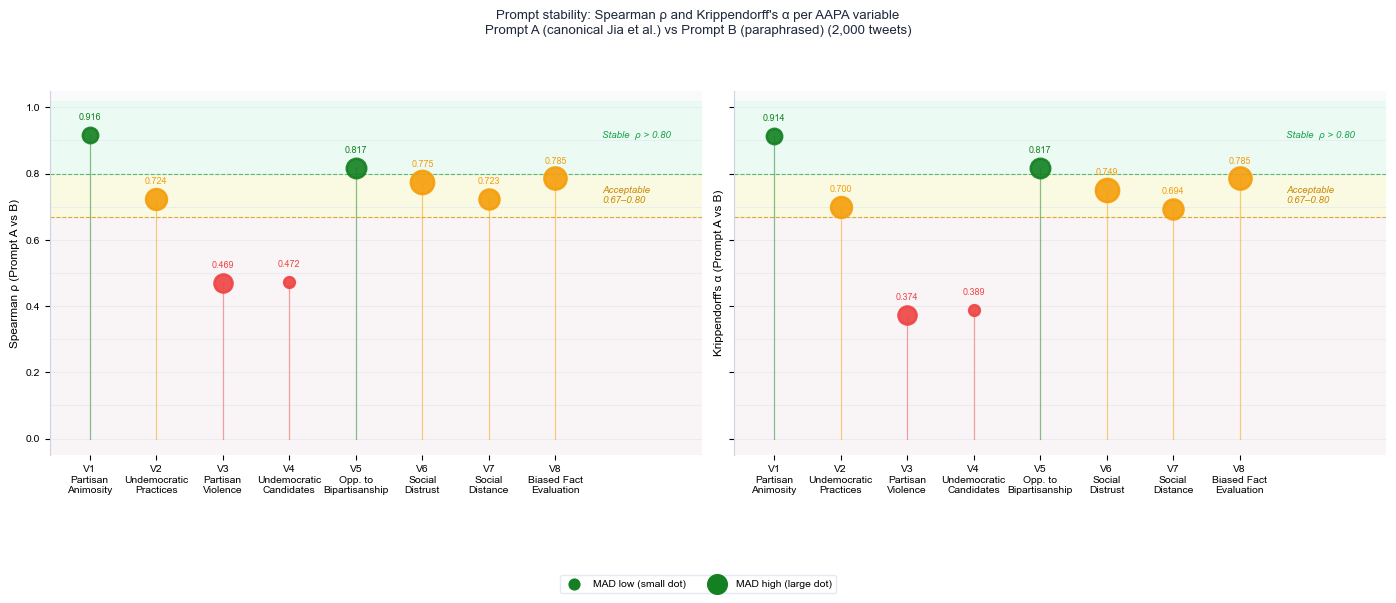

  Saved: study2/stability/figures/figP1_stability_rho_alpha.png


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5), sharey=True)
fig.patch.set_facecolor("white")

metrics = [
    ("spearman_rho",       rho_vals,   "Spearman ρ (Prompt A vs B)"),
    ("krippendorff_alpha", alpha_vals, "Krippendorff's α (Prompt A vs B)"),
]

mad_min, mad_max = mad_vals.min(), mad_vals.max()
dot_sizes = 60 + 220 * (mad_vals - mad_min) / (mad_max - mad_min + 1e-9)

for ax, (metric_key, vals, ylabel) in zip(axes, metrics):
    ax.set_facecolor("#F8FAFC")

    ax.axhspan(THRESHOLD_STABLE, 1.02,                 color="#DCFCE7", alpha=0.45, zorder=0)
    ax.axhspan(THRESHOLD_ACCEPTABLE, THRESHOLD_STABLE, color="#FEF9C3", alpha=0.45, zorder=0)
    ax.axhspan(-0.05, THRESHOLD_ACCEPTABLE,            color="#FEE2E2", alpha=0.20, zorder=0)
    for y in np.arange(0.0, 1.05, 0.1):
        ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)
    ax.axhline(THRESHOLD_STABLE,     color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)
    ax.axhline(THRESHOLD_ACCEPTABLE, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.7, zorder=1)

    for i, v in enumerate(variables):
        val    = vals[i]
        colour = get_var_colour(v, val)
        ax.plot([xi[i], xi[i]], [0, val], color=colour, linewidth=0.9, alpha=0.5, zorder=2)
        ax.scatter(xi[i], val, s=dot_sizes[i], color=colour,
                   edgecolors=colour, linewidths=1.8, zorder=4, alpha=0.9)
        ax.text(xi[i], val + 0.04, f"{val:.3f}",
                fontsize=6.5, ha="center", va="bottom", color=colour)

    ax.text(len(variables) - 0.3, 0.915, "Stable  ρ > 0.80",
            fontsize=7, color="#16A34A", va="center", style="italic")
    ax.text(len(variables) - 0.3, 0.735, "Acceptable\n0.67–0.80",
            fontsize=7, color="#CA8A04", va="center", style="italic")

    ax.set_xticks(xi)
    ax.set_xticklabels([VARIABLE_LABELS[v] for v in variables],
                       fontsize=7.5, multialignment="center")
    ax.set_xlim(-0.6, len(variables) + 1.2)
    ax.set_ylim(-0.05, 1.05)
    ax.set_ylabel(ylabel, fontsize=8.5)
    ax.yaxis.set_major_locator(mticker.MultipleLocator(0.2))
    style_axes(ax)

# Shared legend
legend_elements = [
    plt.scatter([], [], s=60,  color=COLOUR_STABLE, label="MAD low (small dot)"),
    plt.scatter([], [], s=200, color=COLOUR_STABLE, label="MAD high (large dot)"),
]
fig.legend(handles=legend_elements, fontsize=7.5, loc="lower center",
           ncol=3, framealpha=0.9, edgecolor="#E2E8F0",
           bbox_to_anchor=(0.5, -0.04))

fig.suptitle(
    "Prompt stability: Spearman ρ and Krippendorff's α per AAPA variable\n"
    "Prompt A (canonical Jia et al.) vs Prompt B (paraphrased) (2,000 tweets)\n",
    fontsize=9.5, y=1.03, color="#1E293B"
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.22)
save_fig(fig, "figP1_stability_rho_alpha")

### Figure P2: Score-Level Agreement Breakdown

Stacked bar chart showing exact / ±1 / ±2 agreement rates per variable. More interpretable than ρ alone for a non-technical audience.

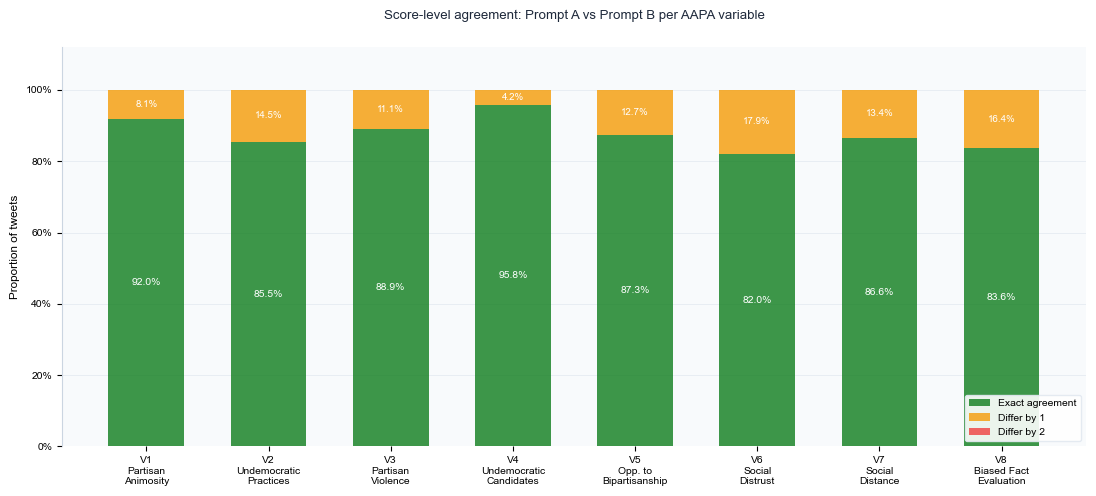

  Saved: study2/stability/figures/figP2_stability_agreement_bars.png


In [33]:
agree_exact = np.array([float(np.mean(np.abs(prompt_a[v].values - prompt_b[v].values) == 0)) for v in variables])
agree_one   = np.array([float(np.mean(np.abs(prompt_a[v].values - prompt_b[v].values) == 1)) for v in variables])
agree_two   = np.array([float(np.mean(np.abs(prompt_a[v].values - prompt_b[v].values) == 2)) for v in variables])

fig, ax = plt.subplots(figsize=(11, 5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

bar_w = 0.62
ax.bar(xi, agree_exact, width=bar_w, color="#148021", alpha=0.82, label="Exact agreement",  zorder=2)
ax.bar(xi, agree_one,   width=bar_w, bottom=agree_exact,
       color="#F59E0B", alpha=0.82, label="Differ by 1", zorder=2)
ax.bar(xi, agree_two,   width=bar_w, bottom=agree_exact + agree_one,
       color="#EF4444", alpha=0.82, label="Differ by 2", zorder=2)

for i in range(len(variables)):
    ax.text(xi[i], agree_exact[i] / 2, f"{agree_exact[i]:.1%}",
            ha="center", va="center", fontsize=7.5, color="white", fontweight="500")
    if agree_one[i] > 0.03:
        ax.text(xi[i], agree_exact[i] + agree_one[i] / 2, f"{agree_one[i]:.1%}",
                ha="center", va="center", fontsize=7, color="white", fontweight="500")
    if agree_two[i] > 0.01:
        ax.text(xi[i], agree_exact[i] + agree_one[i] + agree_two[i] / 2, f"{agree_two[i]:.1%}",
                ha="center", va="center", fontsize=7, color="white", fontweight="500")

for y in np.arange(0.2, 1.05, 0.2):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

# Flag low-variance x-labels
ax.set_xticks(xi)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in variables],
                   fontsize=7.5, multialignment="center")

ax.set_ylim(0, 1.12)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
ax.set_ylabel("Proportion of tweets", fontsize=8.5)
ax.legend(loc="lower right", fontsize=7.5, framealpha=0.9, edgecolor="#E2E8F0")
style_axes(ax)
ax.set_title(
    "Score-level agreement: Prompt A vs Prompt B per AAPA variable\n",
    fontsize=9.5, pad=10, color="#1E293B"
)
plt.tight_layout()
save_fig(fig, "figP2_stability_agreement_bars")

### Figure P3: ρ vs Exact Agreement Scatter; Base Rate Diagnostic

Reveals the base rate artefact: V3/V4 sit upper-left (high exact agreement, low ρ) because both prompts assign score 1 to virtually all tweets, not because they agree on content.

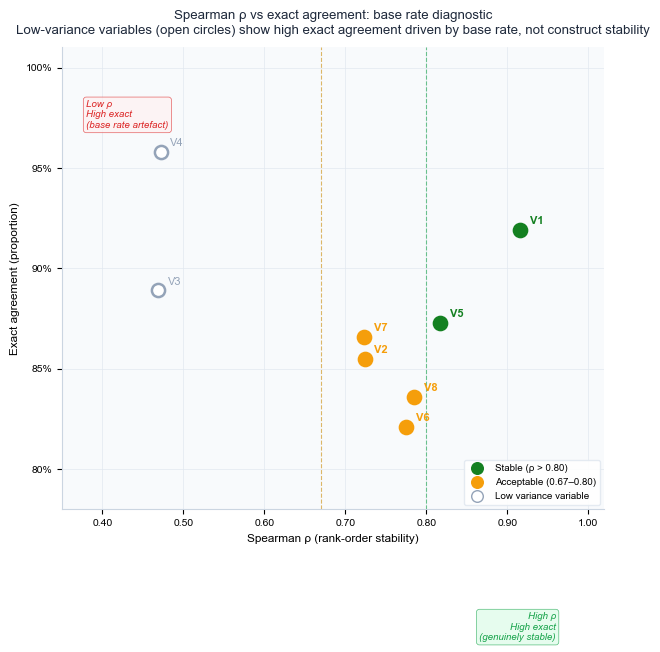

  Saved: study2/stability/figures/figP3_stability_rho_vs_exact.png


In [13]:
fig, ax = plt.subplots(figsize=(7, 6))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

for y in np.arange(0.70, 1.02, 0.05):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)
for x in np.arange(0.30, 1.02, 0.1):
    ax.axvline(x, color="#E2E8F0", linewidth=0.5, zorder=0)

ax.axvline(THRESHOLD_STABLE,     color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)
ax.axvline(THRESHOLD_ACCEPTABLE, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)

# Quadrant annotations
ax.text(0.96, 0.715, "High ρ\nHigh exact\n(genuinely stable)",
        fontsize=7, color="#16A34A", ha="right", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#DCFCE7",
                  edgecolor="#16A34A", linewidth=0.5, alpha=0.7))
ax.text(0.38, 0.97, "Low ρ\nHigh exact\n(base rate artefact)",
        fontsize=7, color="#DC2626", ha="left", style="italic",
        bbox=dict(boxstyle="round,pad=0.3", facecolor="#FFF1F2",
                  edgecolor="#DC2626", linewidth=0.5, alpha=0.7))

for i, v in enumerate(variables):
    rho    = rho_vals[i]
    exact  = exact_vals[i]
    is_lv  = v in LOW_VARIANCE
    colour = "#94A3B8" if is_lv else get_var_colour(v, rho)

    ax.scatter(rho, exact,
               s=90,
               color="white" if is_lv else colour,
               edgecolors=colour, linewidths=1.8,
               zorder=4)
    ax.text(rho + 0.012, exact + 0.003, v,
            fontsize=8, color=colour, fontweight="bold" if not is_lv else "normal")

ax.set_xlabel("Spearman ρ (rank-order stability)", fontsize=8.5)
ax.set_ylabel("Exact agreement (proportion)", fontsize=8.5)
ax.set_xlim(0.35, 1.02)
ax.set_ylim(0.78, 1.01)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
style_axes(ax)
ax.spines["bottom"].set_visible(True)
ax.spines["bottom"].set_color("#CBD5E1")

legend_elements = [
    plt.scatter([], [], s=70, color=COLOUR_STABLE,     edgecolors=COLOUR_STABLE,     label="Stable (ρ > 0.80)"),
    plt.scatter([], [], s=70, color=COLOUR_ACCEPTABLE, edgecolors=COLOUR_ACCEPTABLE, label="Acceptable (0.67–0.80)"),
    plt.scatter([], [], s=70, color="white",           edgecolors="#94A3B8",          label="Low variance variable"),
]
ax.legend(handles=legend_elements, fontsize=7, loc="lower right",
          framealpha=0.9, edgecolor="#E2E8F0")

ax.set_title(
    "Spearman ρ vs exact agreement: base rate diagnostic\n"
    "Low-variance variables (open circles) show high exact agreement driven by base rate, not construct stability",
    fontsize=9.5, pad=10, color="#1E293B"
)
save_fig(fig, "figP3_stability_rho_vs_exact")

### Figure P4: Score Distributions (Prompt A vs Prompt B)

Shows whether the two prompts produce different score distributions, not just different tweet-level assignments.

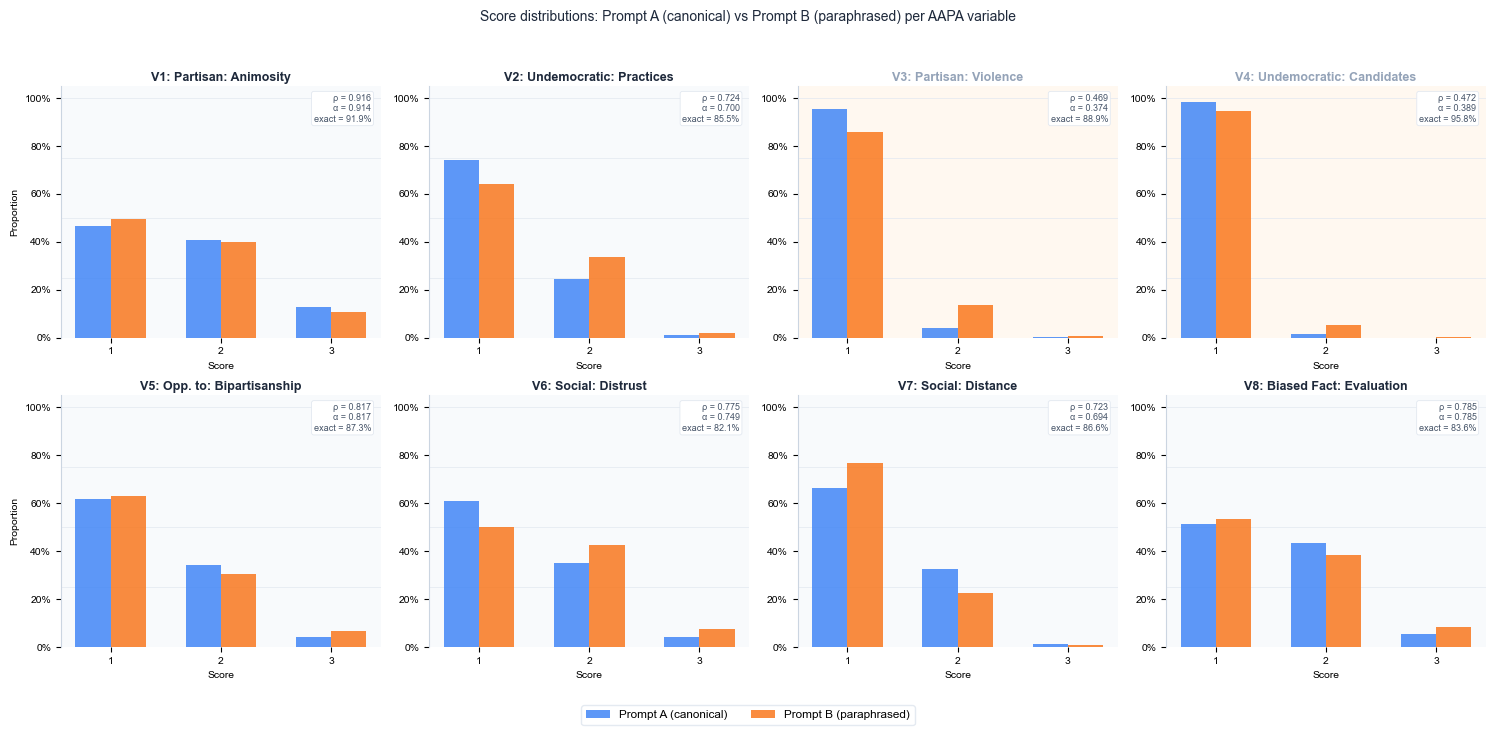

  Saved: study2/stability/figures/figP4_stability_score_distributions.png


In [14]:
fig, axes = plt.subplots(2, 4, figsize=(15, 7), sharey=False)
axes = axes.flatten()
fig.patch.set_facecolor("white")

COLOUR_A = "#3B82F6"
COLOUR_B = "#F97316"
bar_w    = 0.32

for i, v in enumerate(variables):
    ax    = axes[i]
    is_lv = v in LOW_VARIANCE
    ax.set_facecolor("#FFF8F0" if is_lv else "#F8FAFC")

    for y in [0.25, 0.5, 0.75, 1.0]:
        ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

    counts_a = pd.Series(prompt_a[v].values).value_counts(normalize=True).reindex([1, 2, 3], fill_value=0)
    counts_b = pd.Series(prompt_b[v].values).value_counts(normalize=True).reindex([1, 2, 3], fill_value=0)

    ax.bar(np.array([1, 2, 3]) - bar_w / 2, counts_a.values,
           width=bar_w, color=COLOUR_A, alpha=0.82,
           label="Prompt A (canonical)" if i == 0 else "", zorder=2)
    ax.bar(np.array([1, 2, 3]) + bar_w / 2, counts_b.values,
           width=bar_w, color=COLOUR_B, alpha=0.82,
           label="Prompt B (paraphrased)" if i == 0 else "", zorder=2)

    rho   = stability_summary.loc[v, "spearman_rho"]
    alpha = stability_summary.loc[v, "krippendorff_alpha"]
    exact = stability_summary.loc[v, "pct_exact_agree"]
    ax.text(0.97, 0.97,
            f"ρ = {rho:.3f}\nα = {alpha:.3f}\nexact = {exact:.1%}",
            transform=ax.transAxes, fontsize=6.5,
            ha="right", va="top", color="#475569",
            bbox=dict(boxstyle="round,pad=0.25", facecolor="white",
                      edgecolor="#E2E8F0", linewidth=0.6))

    title_colour = "#94A3B8" if is_lv else "#1E293B"
    ax.set_title(f"{VARIABLE_LABELS[v].replace(chr(10), ': ')}",
                 fontsize=9, fontweight="bold", color=title_colour, pad=4)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(["1", "2", "3"], fontsize=7.5)
    ax.set_xlabel("Score", fontsize=7.5)
    ax.set_ylabel("Proportion" if i % 4 == 0 else "", fontsize=7.5)
    ax.set_ylim(0, 1.05)
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.0%}"))
    style_axes(ax)

handles, labels_leg = axes[0].get_legend_handles_labels()
fig.legend(handles, labels_leg, loc="lower center", ncol=2,
           fontsize=8.5, framealpha=0.9, edgecolor="#E2E8F0",
           bbox_to_anchor=(0.5, -0.02))
fig.suptitle(
    "Score distributions: Prompt A (canonical) vs Prompt B (paraphrased) per AAPA variable\n",
    # "Muted titles = low-variance variables",
    fontsize=10, y=1.01, color="#1E293B"
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.10)
save_fig(fig, "figP4_stability_score_distributions")

---
## Phase 2: Ideological Skew

Tests whether deliberately ideological system prompts shift AAPA annotations relative to the neutral baseline. 

The codebook (Prompt A canonical) and rating scale are held constant across all five conditions. Only the system prompt framing changes.

**Design:** 2,000 tweets × 4 framing conditions = 8,000 API calls  
**Neutral baseline:** Prompt A annotations from Phase 1  
**Key metric:** mean signed drift (Framing vs. Neutral) per variable

In [15]:
FRAMING_CHECKPOINT = os.path.join(OUTPUT_DIR, "framing", "checkpoint_phase2.json")

framing_completed = load_checkpoint(FRAMING_CHECKPOINT)
framing_results   = {label: [] for label in FRAMING_LABELS}
annotation_id     = 1

for label in FRAMING_LABELS:
    path = os.path.join(OUTPUT_DIR, "framing", f"framing_{label}.csv")
    if os.path.exists(path):
        existing = pd.read_csv(path)
        framing_results[label] = existing.to_dict("records")
        annotation_id = max(annotation_id, len(existing) + 1)
        print(f"  Resumed [{label}]: {len(existing)} rows")

total_framing = len(df) * len(FRAMING_LABELS)
done_framing  = len(framing_completed)
print(f"\nPhase 2: Ideological skew")
print(f"  Total API calls : {total_framing}")
print(f"  Done            : {done_framing}")
print(f"  Remaining       : {total_framing - done_framing}")

  Checkpoint loaded: 8000 items done
  Resumed [subtle_liberal]: 1972 rows
  Resumed [subtle_conserv]: 1972 rows
  Resumed [extreme_dem]: 1972 rows
  Resumed [extreme_rep]: 1973 rows

Phase 2: Ideological skew
  Total API calls : 8000
  Done            : 8000
  Remaining       : 0


In [16]:
# All 4 framing conditions run for each tweet before moving to the next.
# This minimises time-of-day API variance across conditions for the same tweet.
# Neutral baseline reuses Phase 1 Prompt A annotations, no re-annotation needed.

session = datetime.now().strftime("%Y%m%d_%H%M")

with tqdm(total=total_framing - done_framing, desc="Phase 2: Ideological skew") as pbar:
    for _, tweet_row in df.iterrows():
        tid = tweet_row["tweet_id"]
        for label in FRAMING_LABELS:
            key = (tid, label)
            if key in framing_completed:
                continue
            try:
                annotation = annotate_openai(
                    tweet_row["text"], tweet_row["post_type"],
                    prompt_fn=build_prompt_a,
                    system_prompt=SYSTEM_PROMPTS[label]
                )
                row = annotation_to_row(
                    tweet_row, annotation, annotation_id, session,
                    extra_cols={"framing_condition": label}
                )
                framing_results[label].append(row)
                annotation_id += 1
                framing_completed.add(key)
                save_checkpoint(framing_completed, FRAMING_CHECKPOINT)
                if len(framing_results[label]) % 50 == 0:
                    pd.DataFrame(framing_results[label]).to_csv(
                        os.path.join(OUTPUT_DIR, "framing", f"framing_{label}.csv"),
                        index=False
                    )
                time.sleep(REQUEST_DELAY)
                pbar.update(1)
            except Exception as e:
                if "insufficient_quota" in str(e) or "exceeded your current quota" in str(e):
                    print(f"\n  OpenAI credits exhausted — saving progress and stopping.")
                    for lbl, rows in framing_results.items():
                        if rows:
                            pd.DataFrame(rows).to_csv(
                                os.path.join(OUTPUT_DIR, "framing", f"framing_{lbl}.csv"),
                                index=False
                            )
                    save_checkpoint(framing_completed, FRAMING_CHECKPOINT)
                    break
                print(f"  Failed: tweet {tid}, framing {label}: {e}")
                continue

for label, rows in framing_results.items():
    path = os.path.join(OUTPUT_DIR, "framing", f"framing_{label}.csv")
    pd.DataFrame(rows).to_csv(path, index=False)
    print(f"  Saved [{label}]: {len(rows)} rows")

print("\nPhase 2 complete.")

Phase 2: Ideological skew: 0it [00:00, ?it/s]

  Saved [subtle_liberal]: 1972 rows
  Saved [subtle_conserv]: 1972 rows
  Saved [extreme_dem]: 1972 rows
  Saved [extreme_rep]: 1973 rows

Phase 2 complete.


### Phase 2: Analysis

Three metrics computed for each framing condition vs the neutral baseline:
- **Mean signed drift** (Framing vs. Neutral): positive = inflated scores, negative = suppressed
- **Spearman ρ**: rank-order stability vs neutral
- **Krippendorff's α**: ordinal agreement vs neutral

In [17]:
# Load neutral baseline (Prompt A from Phase 1)
stab_df = pd.read_csv(STABILITY_OUTPUT)
neutral = stab_df[stab_df["prompt_variant"] == "A"].set_index("tweet_id")[SCORE_COLS]
neutral.index = neutral.index.astype(str)

# Load framing conditions
framing_dfs = {}
for label in FRAMING_LABELS:
    path = os.path.join(OUTPUT_DIR, "framing", f"framing_{label}.csv")
    if os.path.exists(path):
        fdf = pd.read_csv(path)
        fdf.index = fdf["tweet_id"].astype(str)
        framing_dfs[label] = fdf[SCORE_COLS]
        print(f"  Loaded [{label}]: {len(fdf)} tweets")
    else:
        print(f"  [{label}]: not found — run Phase 2 first")

# Align all to common tweet IDs
common_all = set(neutral.index)
for fdf in framing_dfs.values():
    common_all &= set(fdf.index)
common_all = sorted(common_all)
neutral = neutral.loc[common_all]
for label in framing_dfs:
    framing_dfs[label] = framing_dfs[label].loc[common_all]
print(f"\nAligned: {len(common_all)} tweets across all conditions")

  Loaded [subtle_liberal]: 1972 tweets
  Loaded [subtle_conserv]: 1972 tweets
  Loaded [extreme_dem]: 1972 tweets
  Loaded [extreme_rep]: 1973 tweets

Aligned: 1972 tweets across all conditions


In [18]:
drift_records = []
rho_records   = []
alpha_records = []

for label, framing_df in framing_dfs.items():
    drift_row = {"condition": label}
    rho_row   = {"condition": label}
    alpha_row = {"condition": label}

    for v in SCORE_COLS:
        drift = float((framing_df[v] - neutral[v]).mean())
        rho, _ = spearmanr(neutral[v], framing_df[v])
        alpha  = krippendorff_alpha([neutral[[v]], framing_df[[v]]], v)
        drift_row[v] = round(drift, 3)
        rho_row[v]   = round(rho, 3)
        alpha_row[v] = round(alpha, 3) if not np.isnan(alpha) else np.nan

    drift_row["mean_drift"] = round(np.mean([drift_row[v] for v in SCORE_COLS]), 3)
    rho_row["mean_rho"]     = round(np.mean([rho_row[v]   for v in SCORE_COLS]), 3)
    alpha_row["mean_alpha"] = round(np.nanmean([alpha_row[v] for v in SCORE_COLS]), 3)

    drift_records.append(drift_row)
    rho_records.append(rho_row)
    alpha_records.append(alpha_row)

drift_summary = pd.DataFrame(drift_records).set_index("condition")
rho_summary   = pd.DataFrame(rho_records).set_index("condition")
alpha_summary = pd.DataFrame(alpha_records).set_index("condition")

drift_summary.to_csv(os.path.join(OUTPUT_DIR, "framing", "framing_drift_summary.csv"))
rho_summary.to_csv(  os.path.join(OUTPUT_DIR, "framing", "framing_rho_summary.csv"))
alpha_summary.to_csv(os.path.join(OUTPUT_DIR, "framing", "framing_alpha_summary.csv"))
print("Saved: framing_drift_summary.csv, framing_rho_summary.csv, framing_alpha_summary.csv")

Saved: framing_drift_summary.csv, framing_rho_summary.csv, framing_alpha_summary.csv


### Table F1: Mean Signed Drift (Framing - Neutral)

In [19]:
display(drift_summary[SCORE_COLS + ["mean_drift"]].round(3))

,V1,V2,V3,V4,V5,V6,V7,V8,mean_drift
condition,,,,,,,,,
subtle_liberal,-0.038,0.019,0.007,0.006,0.038,0.013,0.023,0.013,0.010
subtle_conserv,-0.019,0.023,0.019,-0.002,0.092,0.061,0.047,-0.003,0.027
extreme_dem,-0.020,-0.001,0.042,0.022,0.063,0.013,0.007,-0.046,0.010
extreme_rep,-0.049,-0.008,0.016,0.005,0.034,0.011,-0.012,-0.050,-0.007


### Table F2: Spearman ρ vs Neutral

In [20]:
display(rho_summary[SCORE_COLS + ["mean_rho"]].round(3))

,V1,V2,V3,V4,V5,V6,V7,V8,mean_rho
condition,,,,,,,,,
subtle_liberal,0.942,0.794,0.774,0.631,0.865,0.850,0.856,0.840,0.819
subtle_conserv,0.931,0.802,0.734,0.662,0.834,0.856,0.844,0.825,0.811
extreme_dem,0.921,0.795,0.641,0.537,0.857,0.851,0.867,0.834,0.788
extreme_rep,0.928,0.810,0.723,0.639,0.833,0.850,0.852,0.830,0.808


### Table F3: Krippendorff's α vs Neutral

In [21]:
display(alpha_summary[SCORE_COLS + ["mean_alpha"]].round(3))

,V1,V2,V3,V4,V5,V6,V7,V8,mean_alpha
condition,,,,,,,,,
subtle_liberal,0.940,0.793,0.772,0.624,0.863,0.850,0.855,0.840,0.817
subtle_conserv,0.931,0.800,0.721,0.662,0.822,0.852,0.840,0.825,0.807
extreme_dem,0.920,0.795,0.603,0.487,0.852,0.851,0.867,0.831,0.776
extreme_rep,0.926,0.810,0.713,0.633,0.831,0.850,0.851,0.827,0.805


### Shared Plot Configuration (Phase 2)

In [22]:
from matplotlib.colors import LinearSegmentedColormap

FRAMING_FIGURE_DIR = os.path.join(OUTPUT_DIR, "framing", "figures")
os.makedirs(FRAMING_FIGURE_DIR, exist_ok=True)

CONDITIONS = list(framing_dfs.keys())

CONDITION_LABELS = {
    "subtle_liberal": "Subtle liberal",
    "subtle_conserv": "Subtle conservative",
    "extreme_dem":    "Extreme Democrat",
    "extreme_rep":    "Extreme Republican",
}
CONDITION_COLOURS = {
    "subtle_liberal": "#3B82F6",
    "subtle_conserv": "#EF4444",
    "extreme_dem":    "#1D4ED8",
    "extreme_rep":    "#DC2626",
}

def save_fig_framing(fig, stem):
    path = os.path.join(FRAMING_FIGURE_DIR, stem + ".png")
    fig.savefig(path, dpi=180, bbox_inches="tight")
    plt.show()
    plt.close(fig)
    print(f"  Saved: {path}")

print("Framing plot configuration ready.")

Framing plot configuration ready.


### Figure F1: Heatmap; Krippendorff's α (Framing vs Neutral)

Primary framing overview. Shows which conditions and variables deviate most from neutral.

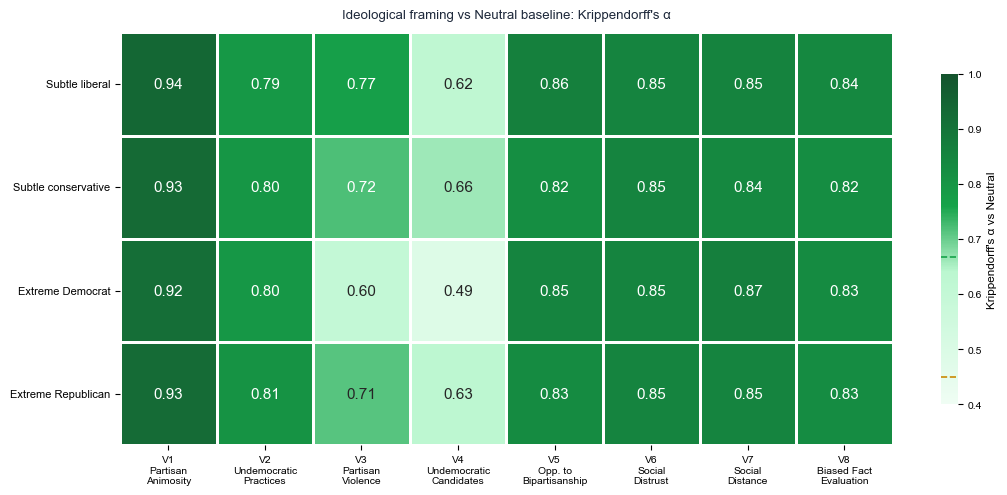

  Saved: study2/framing/figures/figF1a_framing_alpha_heatmap.png


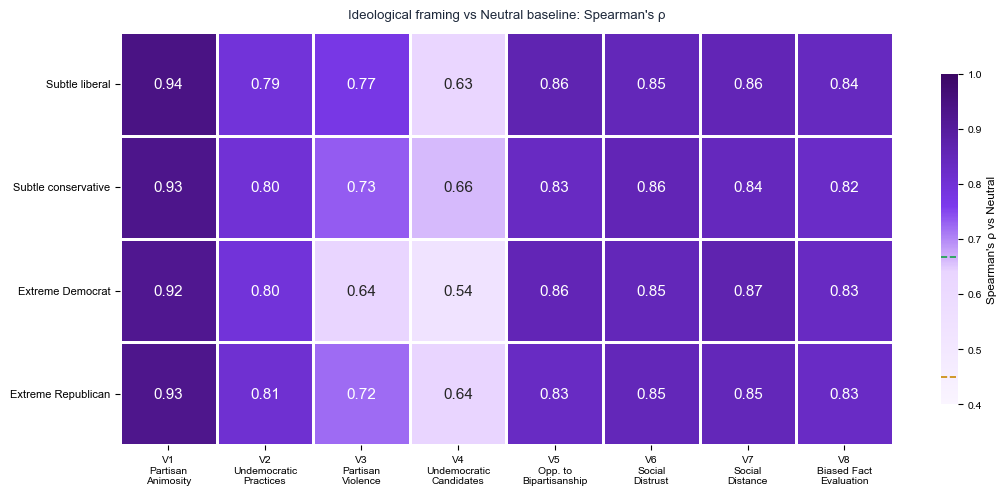

  Saved: study2/framing/figures/figF1b_framing_rho_heatmap.png


In [41]:
# ── Figure F1a: Krippendorff's α heatmap ─────────────────────────────────────
fig_a, ax_a = plt.subplots(figsize=(11, 5))
fig_a.patch.set_facecolor("white")

vals_df_a = alpha_summary[SCORE_COLS].copy().astype(float)
vals_df_a.index   = [CONDITION_LABELS[c] for c in CONDITIONS]
vals_df_a.columns = [VARIABLE_LABELS[v]  for v in SCORE_COLS]
annot_df_a = vals_df_a.map(lambda x: f"{x:.2f}" if not np.isnan(x) else "n/a")

sns.heatmap(
    vals_df_a, ax=ax_a,
    cmap=cmap_greens,
    vmin=0.4, vmax=1.0,
    linewidths=0.8, linecolor="white",
    annot=annot_df_a, fmt="",
    annot_kws={"size": 11},
    cbar_kws={"label": "Krippendorff's α vs Neutral", "shrink": 0.8},
)

cbar_a = ax_a.collections[0].colorbar
for thresh, colour_line in [(0.80, "#16A34A"), (0.67, "#CA8A04")]:
    cbar_a.ax.axhline((thresh - 0.4) / 0.6, color=colour_line,
                      linewidth=1.2, linestyle="--")

ax_a.set_title("Ideological framing vs Neutral baseline: Krippendorff's α",
               fontsize=9.5, pad=10, color="#1E293B")
ax_a.tick_params(axis="x", labelsize=7.5, rotation=0)
ax_a.tick_params(axis="y", labelsize=8,   rotation=0)

plt.tight_layout()
save_fig_framing(fig_a, "figF1a_framing_alpha_heatmap")


# ── Figure F1b: Spearman's ρ heatmap ─────────────────────────────────────────
fig_b, ax_b = plt.subplots(figsize=(11, 5))
fig_b.patch.set_facecolor("white")

vals_df_b = rho_summary[SCORE_COLS].copy().astype(float)
vals_df_b.index   = [CONDITION_LABELS[c] for c in CONDITIONS]
vals_df_b.columns = [VARIABLE_LABELS[v]  for v in SCORE_COLS]
annot_df_b = vals_df_b.map(lambda x: f"{x:.2f}" if not np.isnan(x) else "n/a")

sns.heatmap(
    vals_df_b, ax=ax_b,
    cmap=cmap_purples,
    vmin=0.4, vmax=1.0,
    linewidths=0.8, linecolor="white",
    annot=annot_df_b, fmt="",
    annot_kws={"size": 11},
    cbar_kws={"label": "Spearman's ρ vs Neutral", "shrink": 0.8},
)

cbar_b = ax_b.collections[0].colorbar
for thresh, colour_line in [(0.80, "#16A34A"), (0.67, "#CA8A04")]:
    cbar_b.ax.axhline((thresh - 0.4) / 0.6, color=colour_line,
                      linewidth=1.2, linestyle="--")

ax_b.set_title("Ideological framing vs Neutral baseline: Spearman's ρ",
               fontsize=9.5, pad=10, color="#1E293B")
ax_b.tick_params(axis="x", labelsize=7.5, rotation=0)
ax_b.tick_params(axis="y", labelsize=8,   rotation=0)

plt.tight_layout()
save_fig_framing(fig_b, "figF1b_framing_rho_heatmap")

### Figure F2: Diverging Bar Chart; Mean Signed Drift

Diverging bars show the direction and magnitude of score shift for each framing condition. Positive = framing inflates scores vs neutral; negative = suppresses.

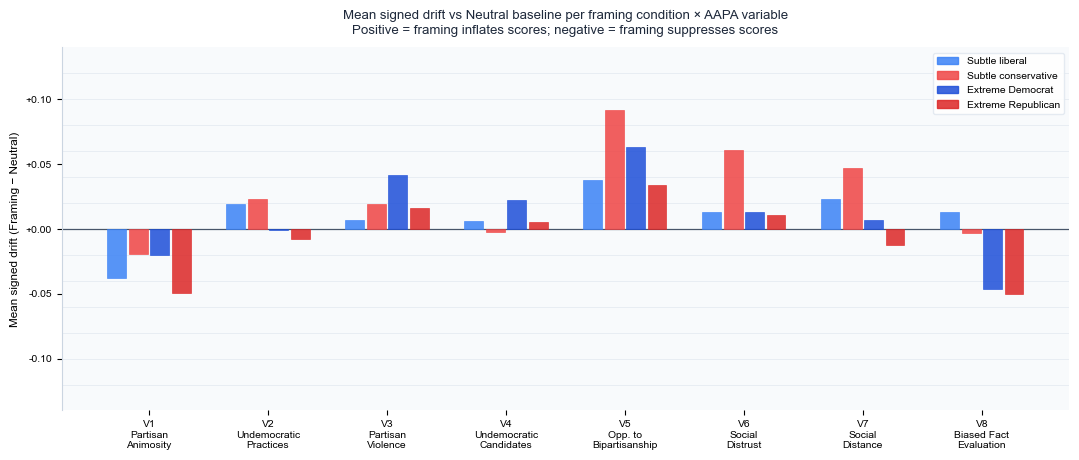

  Saved: study2/framing/figures/figF2_framing_drift_diverging.png


In [24]:
n_conds = len(CONDITIONS)
bar_w   = 0.18
offsets = np.linspace(-(n_conds - 1) * bar_w / 2, (n_conds - 1) * bar_w / 2, n_conds)

fig, ax = plt.subplots(figsize=(13, 5.5))
ax.set_facecolor("#F8FAFC")
fig.patch.set_facecolor("white")

ax.axhline(0, color="#475569", linewidth=0.9, zorder=1)
for y in np.arange(-0.12, 0.14, 0.02):
    ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

for ci, cond in enumerate(CONDITIONS):
    colour = CONDITION_COLOURS[cond]
    for vi, v in enumerate(SCORE_COLS):
        drift  = drift_summary.loc[cond, v]
        ax.bar(
            xi[vi] + offsets[ci], drift,
            width=bar_w * 0.88,
            color=colour,
            alpha=0.85,
            edgecolor=colour,
            linewidth=0.5, zorder=2,
            label=CONDITION_LABELS[cond] if vi == 0 else ""
        )

ax.set_xticks(xi)
ax.set_xticklabels([VARIABLE_LABELS[v] for v in SCORE_COLS],
                   fontsize=7.5, multialignment="center")

ax.set_ylim(-0.14, 0.14)
ax.set_ylabel("Mean signed drift (Framing − Neutral)", fontsize=8.5)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:+.2f}"))
style_axes(ax)

handles = [
    mpatches.Patch(color=CONDITION_COLOURS[c], alpha=0.85, label=CONDITION_LABELS[c])
    for c in CONDITIONS
]

ax.legend(handles=handles, fontsize=7.5, loc="upper right",
          framealpha=0.9, edgecolor="#E2E8F0")

ax.set_title(
    "Mean signed drift vs Neutral baseline per framing condition × AAPA variable\n"
    "Positive = framing inflates scores; negative = framing suppresses scores",
    fontsize=9.5, pad=10, color="#1E293B"
)
plt.subplots_adjust(bottom=0.22)
save_fig_framing(fig, "figF2_framing_drift_diverging")

### Figure F3: ρ vs Absolute Drift; One Panel per Condition

2×2 scatter grid. Each panel plots ρ vs |drift| for one framing condition. Low-variance variables appear as open circles. Separates genuine instability (low ρ + high drift) from base rate artefact (low ρ + low drift).

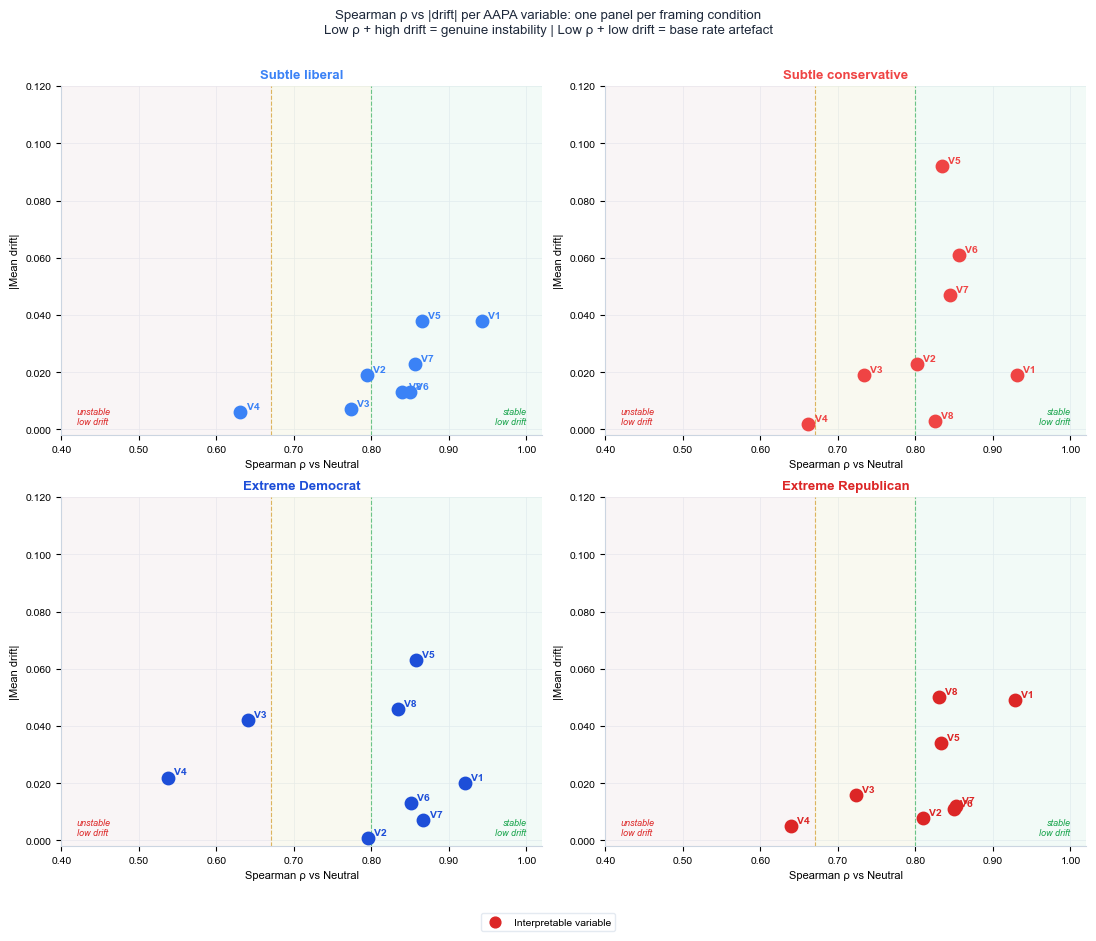

  Saved: study2/framing/figures/figF3_framing_rho_vs_drift.png


In [25]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()
fig.patch.set_facecolor("white")

for ci, cond in enumerate(CONDITIONS):
    ax     = axes[ci]
    colour = CONDITION_COLOURS[cond]
    ax.set_facecolor("#F8FAFC")

    for x in np.arange(0.4, 1.05, 0.1):
        ax.axvline(x, color="#E2E8F0", linewidth=0.5, zorder=0)
    for y in np.arange(0, 0.14, 0.02):
        ax.axhline(y, color="#E2E8F0", linewidth=0.5, zorder=0)

    ax.axvline(THRESHOLD_STABLE,     color="#16A34A", linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)
    ax.axvline(THRESHOLD_ACCEPTABLE, color="#CA8A04", linewidth=0.8, linestyle="--", alpha=0.6, zorder=1)

    ax.axvspan(0.4,                  THRESHOLD_ACCEPTABLE, color="#FEE2E2", alpha=0.2, zorder=0)
    ax.axvspan(THRESHOLD_ACCEPTABLE, THRESHOLD_STABLE,     color="#FEF9C3", alpha=0.2, zorder=0)
    ax.axvspan(THRESHOLD_STABLE,     1.02,                 color="#DCFCE7", alpha=0.2, zorder=0)

    for v in SCORE_COLS:
        rho       = rho_summary.loc[cond, v]
        abs_drift = abs(drift_summary.loc[cond, v])
        dot_col   = colour

        ax.scatter(rho, abs_drift,
                   s=70,
                   color=dot_col,
                   edgecolors=dot_col, linewidths=1.6, zorder=4)
        ax.text(rho + 0.008, abs_drift + 0.001, v,
                fontsize=7.5, color=dot_col,
                fontweight="bold")

    ax.text(1.00, 0.001, "stable\nlow drift",
            fontsize=6.5, color="#16A34A", ha="right", style="italic", va="bottom")
    ax.text(0.42, 0.001, "unstable\nlow drift",
            fontsize=6.5, color="#DC2626", ha="left", style="italic", va="bottom")

    ax.set_xlim(0.40, 1.02)
    ax.set_ylim(-0.002, 0.12)
    ax.set_xlabel("Spearman ρ vs Neutral", fontsize=8)
    ax.set_ylabel("|Mean drift|", fontsize=8)
    ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.2f}"))
    ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f"{x:.3f}"))
    style_axes(ax)
    ax.spines["bottom"].set_visible(True)
    ax.spines["bottom"].set_color("#CBD5E1")
    ax.set_title(CONDITION_LABELS[cond], fontsize=9.5,
                 fontweight="bold", color=colour, pad=6)

legend_elements = [
    plt.scatter([], [], s=60, color=colour, edgecolors=colour, label="Interpretable variable"),
]
fig.legend(handles=legend_elements, fontsize=7.5, loc="lower center", ncol=2,
           framealpha=0.9, edgecolor="#E2E8F0", bbox_to_anchor=(0.5, -0.02))

fig.suptitle(
    "Spearman ρ vs |drift| per AAPA variable: one panel per framing condition\n"
    "Low ρ + high drift = genuine instability | Low ρ + low drift = base rate artefact",
    fontsize=9.5, y=1.01, color="#1E293B"
)
plt.tight_layout()
plt.subplots_adjust(bottom=0.08)
save_fig_framing(fig, "figF3_framing_rho_vs_drift")

---
## Study 2 Summary

In [26]:
print("Study 2 outputs")
print("\nPhase 1 — Prompt stability:")
for f in sorted(os.listdir(os.path.join(OUTPUT_DIR, "stability"))):
    if f.endswith(".csv"):
        path = os.path.join(OUTPUT_DIR, "stability", f)
        print(f"  {f:<50} {len(pd.read_csv(path))} rows")

print("\nPhase 2 — Ideological framing:")
for f in sorted(os.listdir(os.path.join(OUTPUT_DIR, "framing"))):
    if f.endswith(".csv"):
        path = os.path.join(OUTPUT_DIR, "framing", f)
        print(f"  {f:<50} {len(pd.read_csv(path))} rows")

print("\nFigures:")
for subdir, label in [("stability/figures", "Phase 1"), ("framing/figures", "Phase 2")]:
    d = os.path.join(OUTPUT_DIR, subdir)
    if os.path.exists(d):
        for f in sorted(os.listdir(d)):
            if f.endswith(".png"):
                print(f"  [{label}] {f}")

Study 2 outputs

Phase 1 — Prompt stability:
  prompt_stability_results.csv                       4000 rows
  stability_summary.csv                              8 rows

Phase 2 — Ideological framing:
  framing_alpha_summary.csv                          4 rows
  framing_drift_summary.csv                          4 rows
  framing_extreme_dem.csv                            1972 rows
  framing_extreme_rep.csv                            1973 rows
  framing_rho_summary.csv                            4 rows
  framing_subtle_conserv.csv                         1972 rows
  framing_subtle_liberal.csv                         1972 rows

Figures:
  [Phase 1] fig1_stability_dotplot.png
  [Phase 1] fig2_stability_agreement_bars.png
  [Phase 1] fig3_stability_rho_vs_exact.png
  [Phase 1] fig4_stability_score_distributions.png
  [Phase 1] figP1_stability_rho_alpha.png
  [Phase 1] figP2_stability_agreement_bars.png
  [Phase 1] figP3_stability_rho_vs_exact.png
  [Phase 1] figP4_stability_score_distributi